# SigLIP으로 패션 이미지 검색하기 (FAISS + Recall@K)


## 0. 설치 및 설정 (모델 변경)


- faiss_cpu 사용
- 그래프 제목에 한국어 질의를 표시하기 위해 한글 폰트 설치

In [ ]:
!pip install -q faiss-cpu
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

try:
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
except Exception as e:
    print("한글 폰트 설정 실패 (그래프의 한글이 깨질 수 있음):", e)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 61.5 MB/s eta 0:00:00


모델 siglip으로 변경

In [ ]:
MODEL_ID = "google/siglip-base-patch16-256-multilingual"
N_IMAGES = 600   # 검색 대상 이미지 수 (수백 장)
SEED = 42        # 같은 이미지가 뽑히도록 고정
TOP_K = 5        # 검색 결과로 보여줄 장수

## 1. 이미지 데이터셋 불러오기

ashraq/fashion-product-images-small

: 패션 상품 이미지 약 44,000장과 상품 정보(상품명, 성별, 종류, 색상 등)가 들어 있는 데이터셋
- 상품명을 캡션처럼 사용
- 같은 상품명이 여러 개 있으면 Recall@K에서 정답이 애매해짐

  -> 상품명이 겹치는 상품은 제외하고 그중 N_IMAGES 장을 뽑음 *상품명 1개 = 정답 사진 1장)

In [ ]:
from datasets import load_dataset
import pandas as pd

full = load_dataset("ashraq/fashion-product-images-small", split="train")
meta = full.remove_columns("image").to_pandas()

COLS = ["productDisplayName", "gender", "articleType", "baseColour"]
meta = meta.dropna(subset=COLS)
meta = meta.drop_duplicates(subset="productDisplayName", keep=False)  # 이름이 겹치는 상품은 전부 제외

sampled = meta.sample(n=N_IMAGES, random_state=SEED)
gallery = full.select(sampled.index.tolist())              # 검색 대상 이미지
gallery_meta = sampled[COLS].reset_index(drop=True)        # i번째 행 = gallery의 i번째 이미지

print(f"전체 {len(full):,}장 → 이름 중복 제거 후 {len(meta):,}장 → 사용 {len(gallery):,}장")

필터링 결과: 전체 44,072장 → 이름 중복 제거 후 25,712장 → 사용 600장

,productDisplayName,gender,articleType,baseColour
0,Aneri Women Blue & Brown Printed Kurta,Women,Kurtas,Blue
1,Puma Men's Graphic Black Red T-shirt,Men,Tshirts,Black
2,Hanes Women Pack of 3 Briefs,Women,Briefs,Black
3,Carlton London Men Blue Casual Shoes,Men,Casual Shoes,Blue
4,FIFA Mens Heritage Collection Grey Track Pants,Men,Track Pants,Grey



[종류 상위 10개]
 articleType
Tshirts         115
Sports Shoes     50
Casual Shoes     40
Shirts           34
Watches          29
Tops             22
Briefs           21
Kurtas           19
Handbags         18
Flip Flops       14

[색상 상위 10개]
 baseColour
Black        127
White         71
Blue          62
Grey          45
Brown         36
Red           33
Green         29
Pink          27
Purple        25
Navy Blue     17


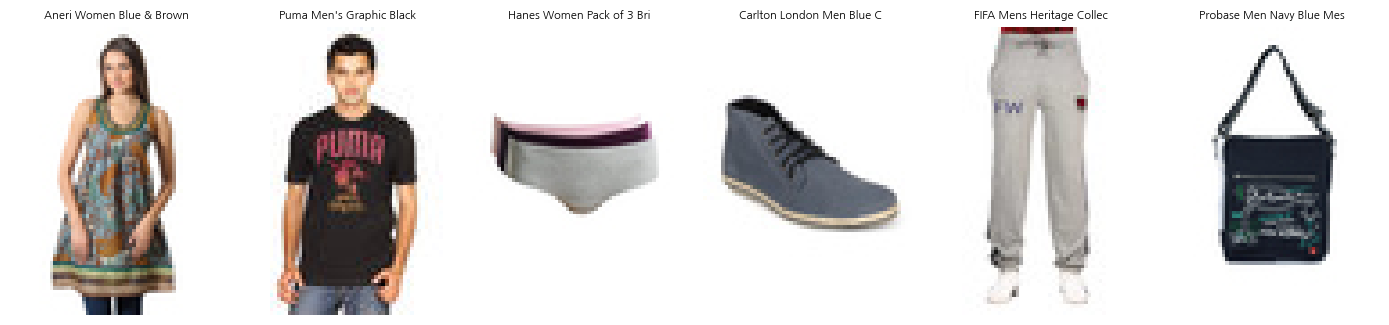

In [ ]:
display(gallery_meta.head())
print("\n[종류 상위 10개]\n", gallery_meta["articleType"].value_counts().head(10).to_string())
print("\n[색상 상위 10개]\n", gallery_meta["baseColour"].value_counts().head(10).to_string())

# 샘플 이미지 확인
fig, axes = plt.subplots(1, 6, figsize=(14, 3.5))
for ax, i in zip(axes, range(6)):
    ax.imshow(gallery[i]["image"]); ax.axis("off")
    ax.set_title(gallery_meta.loc[i, "productDisplayName"][:25], fontsize=8)
plt.tight_layout(); plt.show()

## 2. Offline Indexing: SigLIP 이미지 임베딩 → FAISS 인덱스 저장

###모델 준비

In [ ]:
import torch
import numpy as np
import faiss
from transformers import AutoModel, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

# SigLIP 모델 (이미지 인코더 + 텍스트 인코더) 불러오기
model = AutoModel.from_pretrained(MODEL_ID).to(device).eval() # 학습이 아닌 추론 모드 설정

# AutoProcessor: 텍스트 토큰으로 쪼갬
processor = AutoProcessor.from_pretrained(MODEL_ID)

# 학습된 temperature, bias
T = model.logit_scale.exp().item()
B = model.logit_bias.item()
print(f"device={device}, temperature T={T:.1f}, bias B={B:.1f}")

### 이미지 임베딩 함수

**to_emb**
: 모델 출력에서 임베딩을 꺼내 길이 1로 정규화
- (transformers 버전에 따라 출력 형태가 달라서 둘 다 처리)

In [ ]:
def to_emb(out):
    emb = out if isinstance(out, torch.Tensor) else out.pooler_output
    return emb / emb.norm(dim=-1, keepdim=True)

**embed_images** : 이미지 목록을 64장씩 나눠서
- RGB로 변환 (흑백·투명 배경 이미지 대비)
- processor로 전처리 → GPU로 이동
- 이미지 인코더로 벡터화 → 정규화 → CPU로 이동
- 전부 합쳐서 FAISS가 받는 float32 numpy 배열로 변환

In [ ]:
@torch.no_grad()
def embed_images(images, batch_size=64):
    embs = []
    for i in range(0, len(images), batch_size):
        batch = [img.convert("RGB") for img in images[i:i + batch_size]]
        inputs = processor(images=batch, return_tensors="pt").to(device)
        embs.append(to_emb(model.get_image_features(**inputs)).cpu())
    return torch.cat(embs).numpy().astype("float32")

### 텍스트 임베딩 함수

**embed_texts**: embed_images와 같은 구조

- SigLIP은 학습 때 모든 문장을 64토큰으로 패딩했기 때문에 검색 때도 똑같이 해야함
- 여러 질의를 한번에 처리하도록 배치로 짬 -> 평가에서 상품명 600개를 한꺼번에 임베딩할 때도 이 함수 사용

In [ ]:
@torch.no_grad()
def embed_texts(texts, batch_size=64):
    embs = []
    for i in range(0, len(texts), batch_size):
        inputs = processor(text=texts[i:i + batch_size], padding="max_length", max_length=64,
                           truncation=True, return_tensors="pt").to(device)
        embs.append(to_emb(model.get_text_features(**inputs)).cpu())
    return torch.cat(embs).numpy().astype("float32")

### FAISS 인덱스 만들기

In [ ]:
import time

start = time.time()
image_embs = embed_images(gallery["image"]) # 이미지 600장 전부 벡터화
faiss.normalize_L2(image_embs) # 정규화

index = faiss.IndexFlatIP(image_embs.shape[1])  # 내적으로 비교하는 인덱스 생성
index.add(image_embs) # 600개 벡터 저장

print(f"인덱싱 완료: {index.ntotal}장, 차원 {image_embs.shape[1]}, {time.time() - start:.1f}초")

faiss.write_index(index, "fashion_siglip.index")  # (선택) 인덱스 파일로 저장

인덱싱 완료: 600장, 차원 768, 17.6초


## 3. Online Inference + Look-up : 텍스트 질의 → FAISS 검색 → 상위 k장

- search: 질의를 벡터로 바꿔 FAISS에서 상위 k개를 찾고, 번호로 상품 정보를 조회
- show_results: 결과 이미지와 확률, 상품명 출력

### 검색 함수

In [ ]:
def search(query, k=TOP_K):
    q = embed_texts([query]) # 질의 -> siglip 텍스트 벡터 (online inference)
    faiss.normalize_L2(q) # 정규화
    scores, ids = index.search(q, k) # FAISS에서 내적이 큰 순으로 k개 -> 점수
    results = []
    for s, i in zip(scores[0], ids[0]):
        row = gallery_meta.iloc[int(i)] # 번호로 상품 정보 조회 (look-up)
        results.append({
            "idx": int(i), "cos": float(s),
            "prob": float(1 / (1 + np.exp(-(T * s + B)))),   # 코사인 점수를 짝일 확률로 반환
            "name": row.productDisplayName, "type": row.articleType, "color": row.baseColour,
        })
    return results

### 결과 출력 함수
결과: 이미지마다 {번호, 코사인, 확률, 상품명, 종류, 색상}을 담은 목록

In [ ]:
def show_results(query, results):
    fig, axes = plt.subplots(1, len(results), figsize=(2.6 * len(results), 3.8))
    for ax, r in zip(np.atleast_1d(axes), results):
        ax.imshow(gallery[r["idx"]]["image"]); ax.axis("off")
        ax.set_title(f"{r['color']} / {r['type']}\nprob={r['prob']:.3f}", fontsize=9)
    fig.suptitle(f"질의: {query}", fontsize=12)
    plt.tight_layout(); plt.show()
    for rank, r in enumerate(results, 1):
        print(f"  {rank}. ({r['prob']:.3f}, cos={r['cos']:.3f}) {r['name']}")

###질의 하나로 동작을 확인

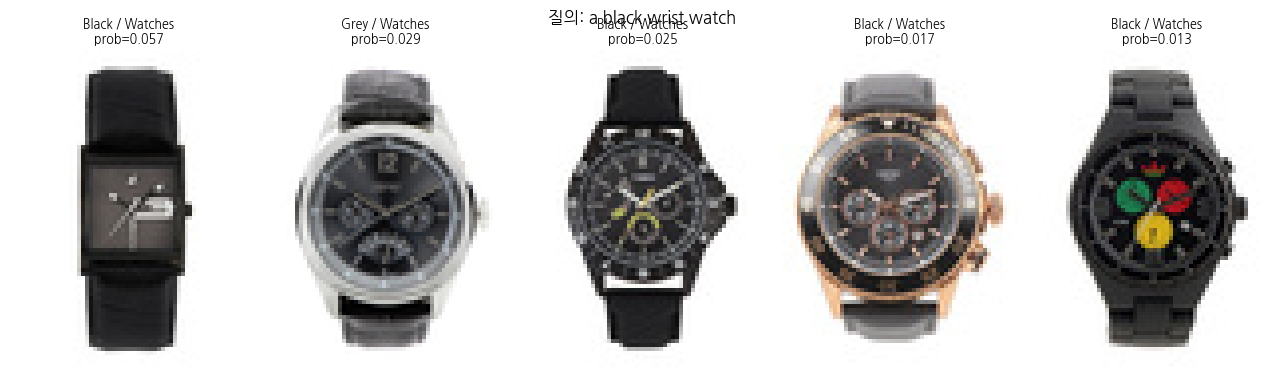

  1. (0.057, cos=0.091) Fastrack Women Black Dial Watch NA9735NL02
  2. (0.029, cos=0.085) Esprit Men Grey Dial Watch
  3. (0.025, cos=0.083) Timex Men Black Dial Watch T2N520
  4. (0.017, cos=0.080) Esprit Men  Black Dial Chronograph Watch
  5. (0.013, cos=0.077) ADIDAS Original Unisex Black Chronograph Watch ADH2630


In [ ]:
query = "a black wrist watch"
show_results(query, search(query))

### 영어 vs 한국어 질의 비교
같은 의미의 영어·한국어 질의를 각각 검색

- 겹친 사진 수: 영어·한국어 상위 k장 중 같은 사진의 수

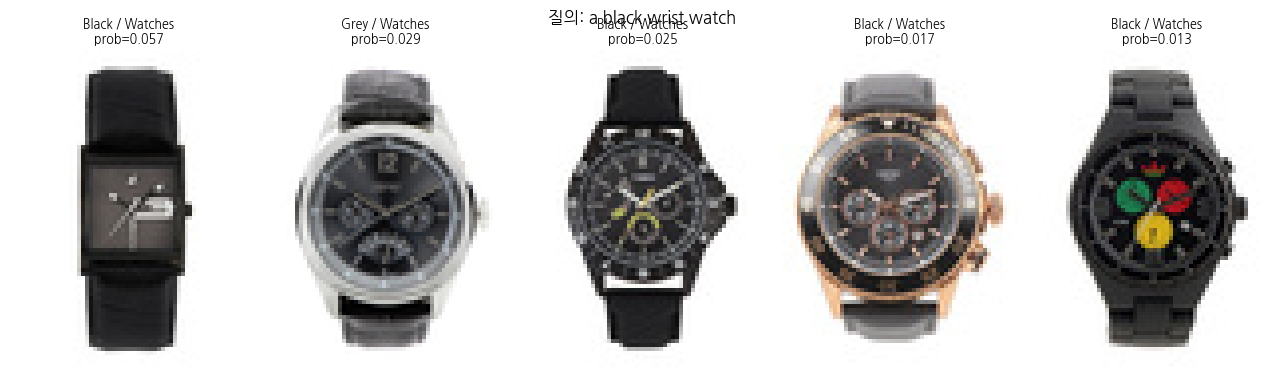

  1. (0.057, cos=0.091) Fastrack Women Black Dial Watch NA9735NL02
  2. (0.029, cos=0.085) Esprit Men Grey Dial Watch
  3. (0.025, cos=0.083) Timex Men Black Dial Watch T2N520
  4. (0.017, cos=0.080) Esprit Men  Black Dial Chronograph Watch
  5. (0.013, cos=0.077) ADIDAS Original Unisex Black Chronograph Watch ADH2630


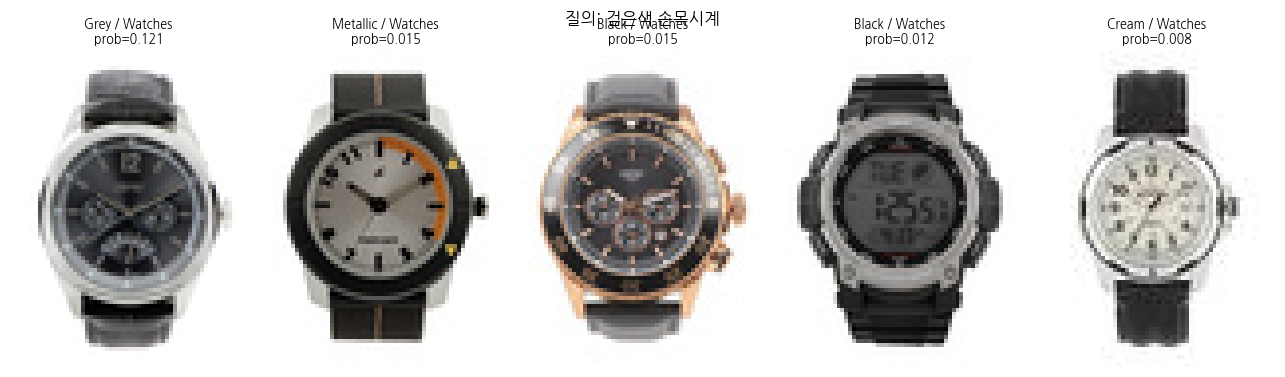

  1. (0.121, cos=0.098) Esprit Men Grey Dial Watch
  2. (0.015, cos=0.078) Fastrack Men Gunmetal-Toned Dial Watch NA3015AL01
  3. (0.015, cos=0.078) Esprit Men  Black Dial Chronograph Watch
  4. (0.012, cos=0.077) Q&Q Men Black Digital Watch M119J002Y
  5. (0.008, cos=0.073) Timex Men Off White Dial Watch

▶ 겹친 사진 수: 2/5


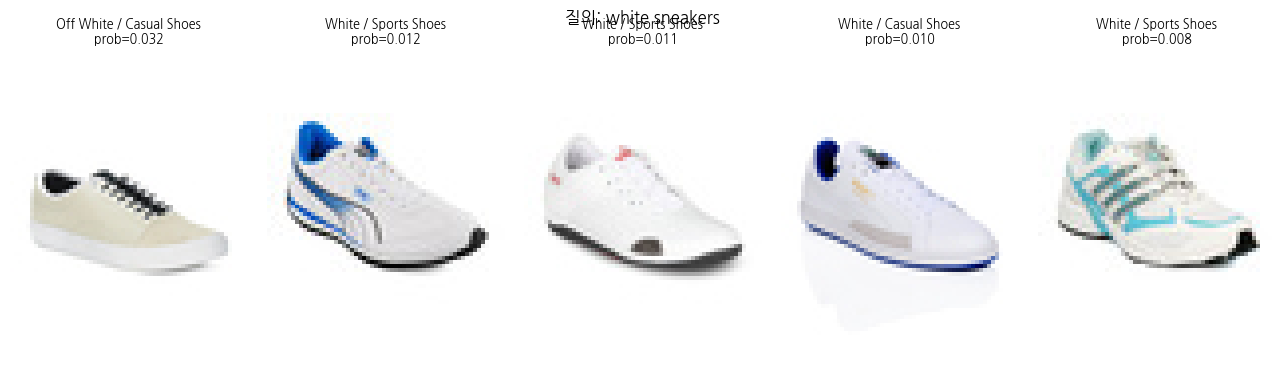

  1. (0.032, cos=0.085) Vans Men Cream Larkin Shoes
  2. (0.012, cos=0.076) Puma Men Silly Point White Sports Shoes
  3. (0.011, cos=0.075) Puma Men Route Ducati White Shoe
  4. (0.010, cos=0.075) Puma Men Match Classics White Shoes
  5. (0.008, cos=0.073) ADIDAS Women Sprint Speed Low White Blue Shoe


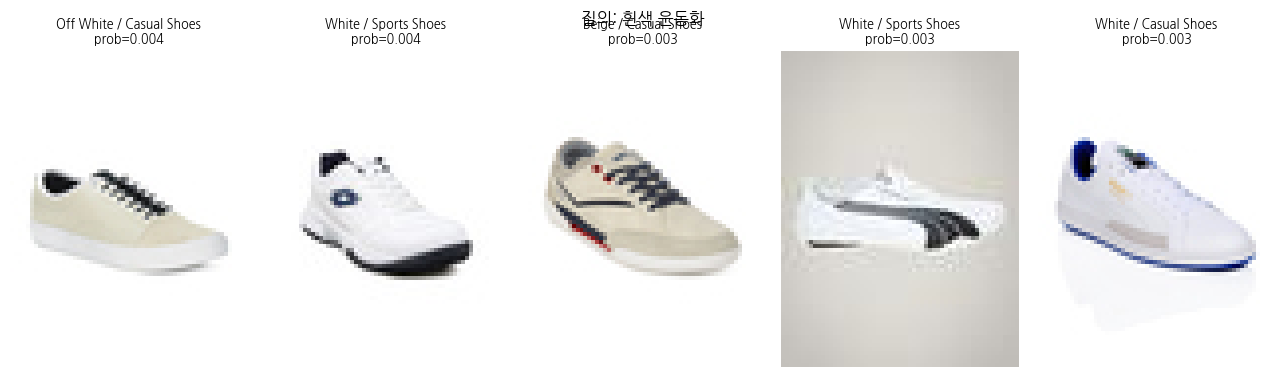

  1. (0.004, cos=0.067) Vans Men Cream Larkin Shoes
  2. (0.004, cos=0.066) Lotto Men's Swing White Blue Shoe
  3. (0.003, cos=0.064) Gas Men Flint Grey Shoes
  4. (0.003, cos=0.064) Puma Men's Jiyu Slip On Sneaker
  5. (0.003, cos=0.062) Puma Men Match Classics White Shoes

▶ 겹친 사진 수: 2/5


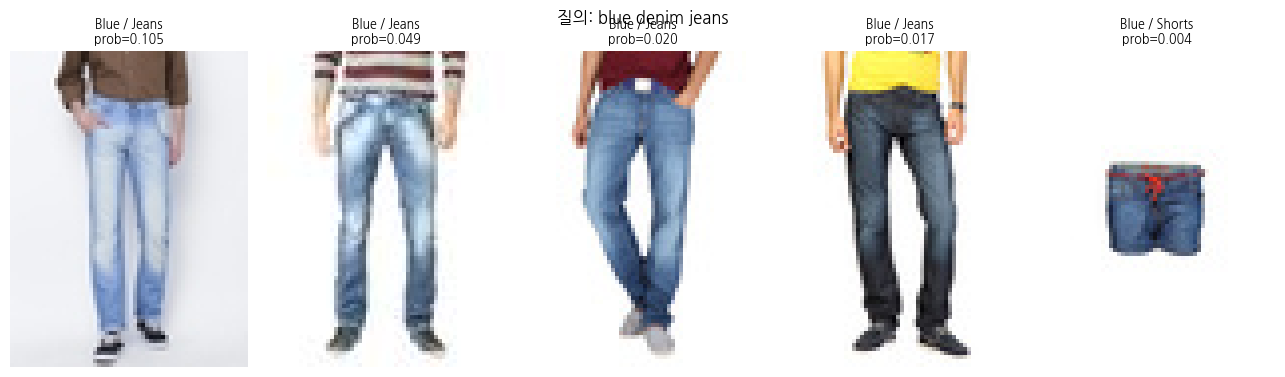

  1. (0.105, cos=0.097) John Players Men Blue Slim Fit Low-Rise Clean Look Stretchable Jeans
  2. (0.049, cos=0.089) Spykar Men Blue Washed Jeans
  3. (0.020, cos=0.081) Deni Yo Men Blue Slim Fit Jeans
  4. (0.017, cos=0.080) Lee Men BUD PWL Blue Jeans
  5. (0.004, cos=0.066) Gini and Jony Girl's Arella Blue Kidswear


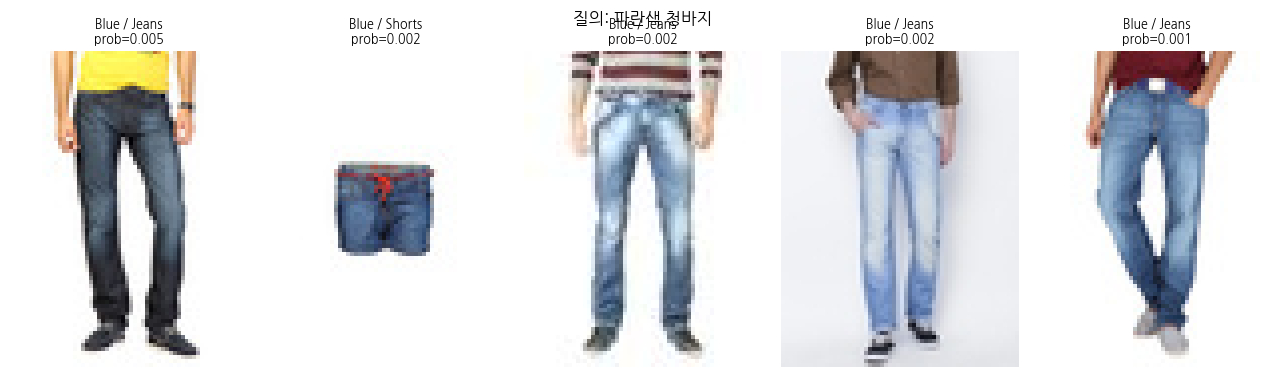

  1. (0.005, cos=0.068) Lee Men BUD PWL Blue Jeans
  2. (0.002, cos=0.062) Gini and Jony Girl's Arella Blue Kidswear
  3. (0.002, cos=0.060) Spykar Men Blue Washed Jeans
  4. (0.002, cos=0.060) John Players Men Blue Slim Fit Low-Rise Clean Look Stretchable Jeans
  5. (0.001, cos=0.057) Deni Yo Men Blue Slim Fit Jeans

▶ 겹친 사진 수: 5/5


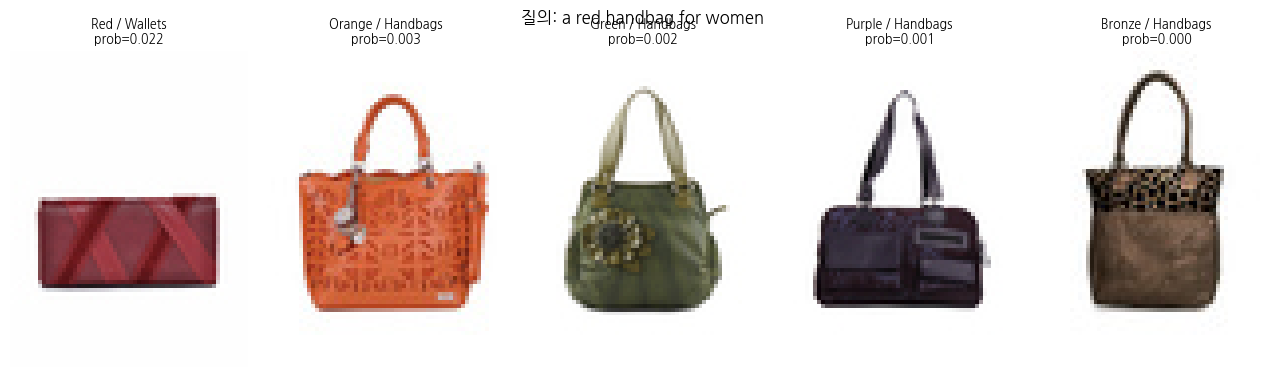

  1. (0.022, cos=0.082) Baggit Women Era Taj Red Wallet
  2. (0.003, cos=0.062) Mod'acc Women Orange Handbag
  3. (0.002, cos=0.058) Murcia Women Casual Green Handbag
  4. (0.001, cos=0.050) Baggit Women Galaxy Taj Purple Handbag
  5. (0.000, cos=0.033) Murcia Women Bronze Handbag


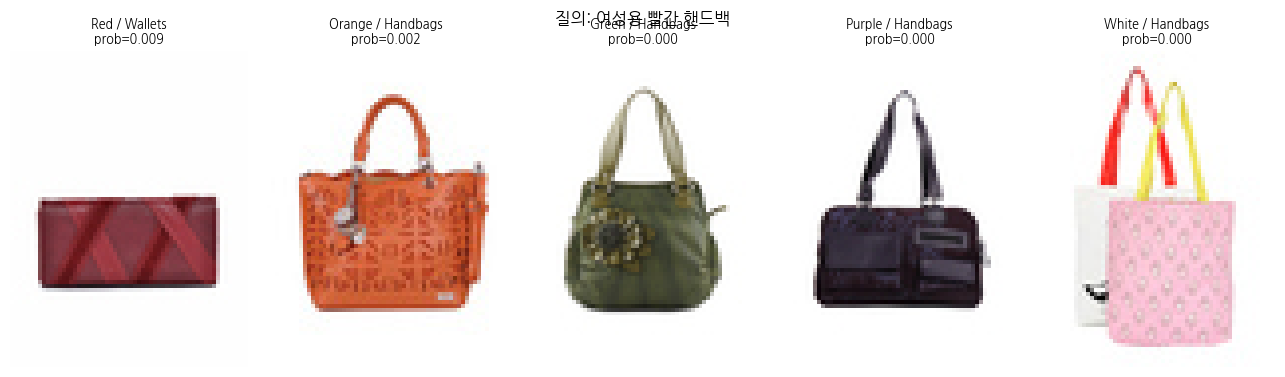

  1. (0.009, cos=0.074) Baggit Women Era Taj Red Wallet
  2. (0.002, cos=0.059) Mod'acc Women Orange Handbag
  3. (0.000, cos=0.047) Murcia Women Casual Green Handbag
  4. (0.000, cos=0.042) Baggit Women Galaxy Taj Purple Handbag
  5. (0.000, cos=0.034) Be For Bag Women White and Pink Combo pack Tote Bags

▶ 겹친 사진 수: 4/5


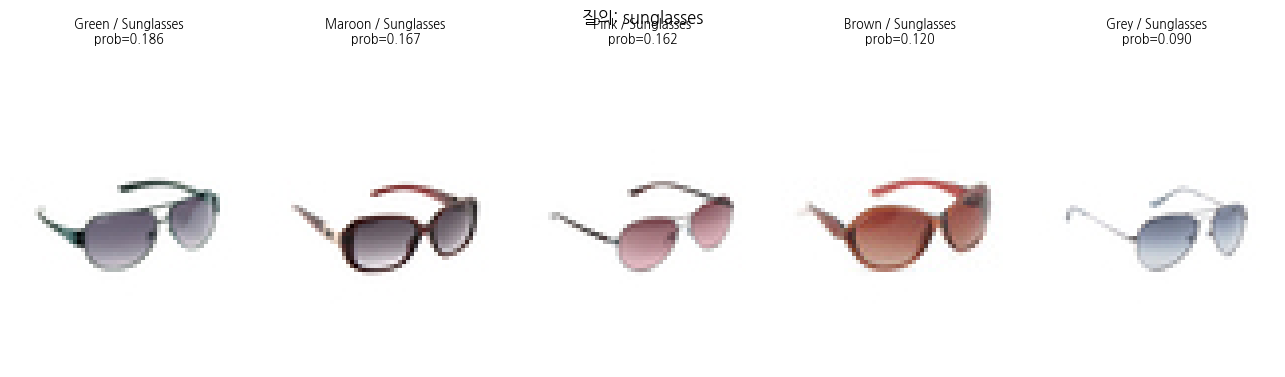

  1. (0.186, cos=0.103) Mayhem Men Rectangular Sunglasses 1020-207
  2. (0.167, cos=0.102) M tv Women My Fab Eyewear Maroon Sunglasses
  3. (0.162, cos=0.101) Idee Men Pink Sunglasses
  4. (0.120, cos=0.098) United Colors of Benetton Women Casual Brown Sunglasses
  5. (0.090, cos=0.095) Park Avenue Men Blue Sunglasses


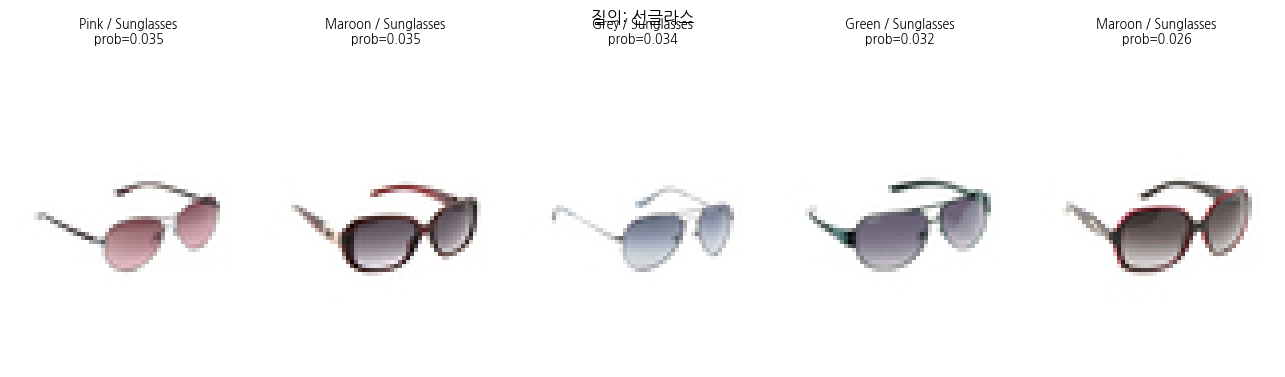

  1. (0.035, cos=0.086) Idee Men Pink Sunglasses
  2. (0.035, cos=0.086) M tv Women My Fab Eyewear Maroon Sunglasses
  3. (0.034, cos=0.086) Park Avenue Men Blue Sunglasses
  4. (0.032, cos=0.085) Mayhem Men Rectangular Sunglasses 1020-207
  5. (0.026, cos=0.084) Idee Women Funky Eyewear Maroon Sunglasses

▶ 겹친 사진 수: 4/5


In [ ]:
PAIRS = [
    ("a black wrist watch", "검은색 손목시계"),
    ("white sneakers", "흰색 운동화"),
    ("blue denim jeans", "파란색 청바지"),
    ("a red handbag for women", "여성용 빨간 핸드백"),
    ("sunglasses", "선글라스"),
]

for en, ko in PAIRS:
    en_res, ko_res = search(en), search(ko)
    show_results(en, en_res)
    show_results(ko, ko_res)
    overlap = len({r["idx"] for r in en_res} & {r["idx"] for r in ko_res})
    print(f"\n▶ 겹친 사진 수: {overlap}/{TOP_K}")
    print("=" * 70)

### 관련 없는 질의

- 베이스 노트북: 관련 없는 결과를 distance로 걸러낼 수 있다고 설명함
- SigLIP은 점수를 sigmoid 확률로 바꿀 수 있어서, 데이터에 없는 질의는 확률이 0에 가깝게 나옴

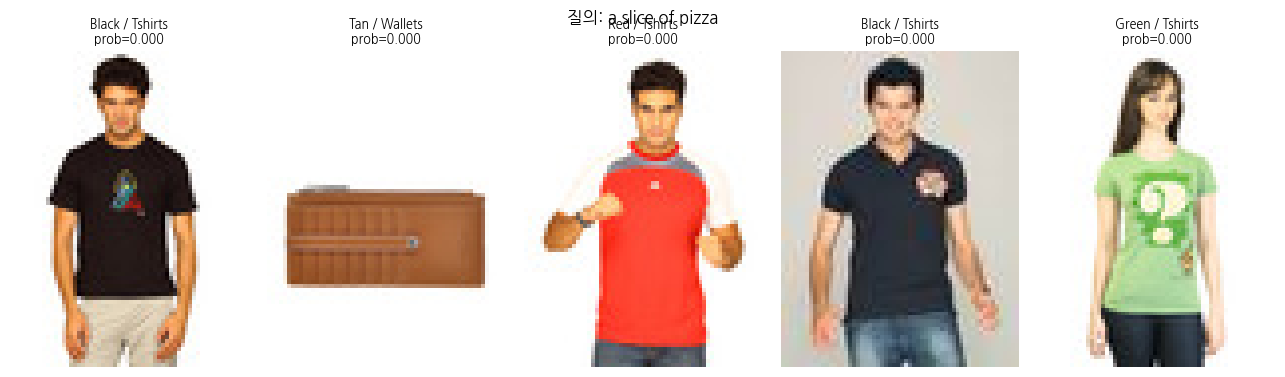

  1. (0.000, cos=0.026) Urban Yoga Men's Mind Body Soul Black T-shirt
  2. (0.000, cos=0.021) Lino Perros Women Small Tan Wallet
  3. (0.000, cos=0.007) ADIDAS Men's Coffer Red T-shirt
  4. (0.000, cos=0.006) UCB Men's Polo Neck With Badge Black T-shirt
  5. (0.000, cos=0.005) Little Miss Women Printed Green Tshirt


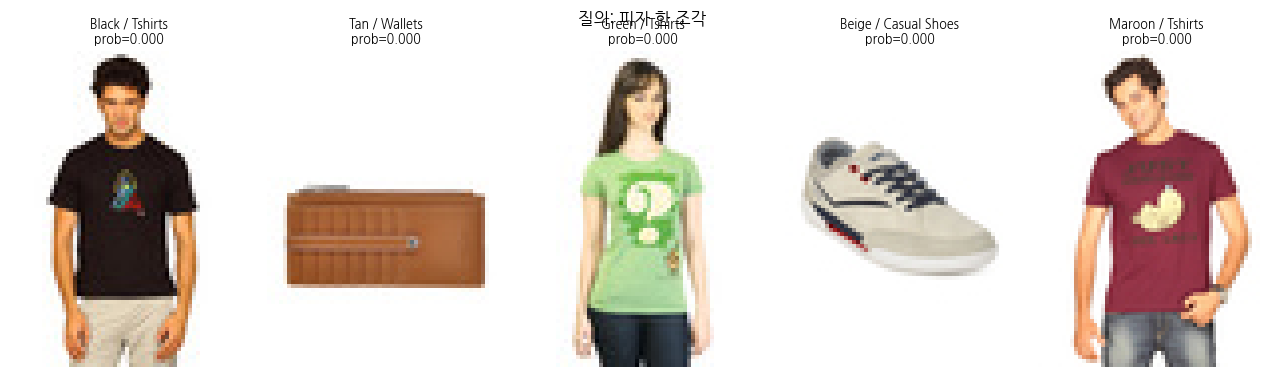

  1. (0.000, cos=0.006) Urban Yoga Men's Mind Body Soul Black T-shirt
  2. (0.000, cos=0.004) Lino Perros Women Small Tan Wallet
  3. (0.000, cos=-0.002) Little Miss Women Printed Green Tshirt
  4. (0.000, cos=-0.004) Gas Men Flint Grey Shoes
  5. (0.000, cos=-0.006) Mr.Men Maroon Printed T-shirt


In [ ]:
for q in ["a slice of pizza", "피자 한 조각"]:
    show_results(q, search(q))

## 4. Recall@K: 상품명으로 검색했을 때 정답 사진이 상위 K장 안에 든 비율

- 질의: 각 상품의 상품명 (`N_IMAGES`개)
- 정답: 그 상품명의 원래 사진 (1장)
- Recall@K = 정답 사진이 상위 K장 안에 든 질의 수 / 전체 질의 수
- `랜덤 기대값`: 아무렇게나 K장을 골랐을 때의 Recall (= K / 이미지 수). 이것과 비교하면 모델이 얼마나 잘하는지 알 수 있음

### Recall@K

Recall@K 계산

In [ ]:
KS = [1, 5, 10]

queries = gallery_meta["productDisplayName"].tolist()
Q = embed_texts(queries)
faiss.normalize_L2(Q)
_, ids = index.search(Q, max(KS))

gt = np.arange(len(queries))       # i번째 질의의 정답 = i번째 이미지
hits = ids == gt[:, None]          # (질의 수, max K): 정답이 그 순위에 있으면 True

recall_df = pd.DataFrame([
    {"구분": "SigLIP", **{f"Recall@{k}": hits[:, :k].any(axis=1).mean() for k in KS}},
    {"구분": "랜덤 기대값", **{f"Recall@{k}": k / len(gallery) for k in KS}},
]).round(3)
display(recall_df)

,구분,Recall@1,Recall@5,Recall@10
0,SigLIP,0.565,0.888,0.963
1,랜덤 기대값,0.002,0.008,0.017


틀린 예시 보기

질의: Timberland Men Claremont Plaid Blue Shirt
  정답 순위: 7위 / 1등으로 나온 상품: Spykar Men Check Brown Shirts


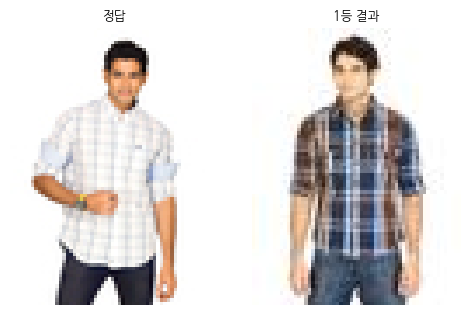

질의: DKNY Women White Dial Watch NY8482
  정답 순위: 10위 밖 / 1등으로 나온 상품: Fossil Women White Dial Chronograph Watch ES2944


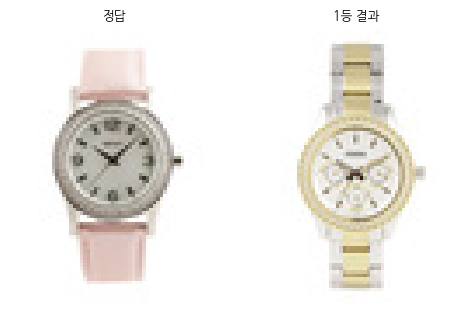

질의: Homme Men Black Formal Oxford Shoes
  정답 순위: 4위 / 1등으로 나온 상품: Carlton London Men Formal Black Formal Shoes


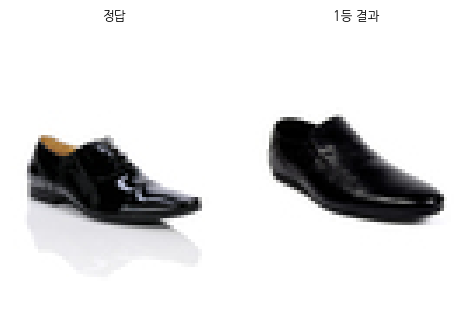

In [ ]:
# Recall@1에서 틀린 예시 3개: 정답 대신 무엇이 1등으로 나왔는지
misses = np.where(~hits[:, 0])[0]
rng = np.random.default_rng(SEED)

for qi in rng.choice(misses, size=min(3, len(misses)), replace=False):
    top1 = ids[qi, 0]
    rank = np.where(hits[qi])[0]
    rank_str = f"{rank[0] + 1}위" if len(rank) else f"{max(KS)}위 밖"
    print(f"질의: {queries[qi]}")
    print(f"  정답 순위: {rank_str} / 1등으로 나온 상품: {gallery_meta.loc[top1, 'productDisplayName']}")

    fig, axes = plt.subplots(1, 2, figsize=(5, 3.2))
    axes[0].imshow(gallery[int(qi)]["image"]); axes[0].set_title("정답", fontsize=9)
    axes[1].imshow(gallery[int(top1)]["image"]); axes[1].set_title("1등 결과", fontsize=9)
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

### Precision@K: 영어 vs 한국어

상품명은 영어라서 4-1은 영어로만 평가할 수 있습니다. 대신 이 데이터셋에는 **색상**과 **종류** 정보가 따로 있으므로, 사전을 이용해 같은 조건의 영어·한국어 질의를 자동으로 만들고 채점합니다.

평가용 질의 자동 생성

**사전 두개**
- COLORS: 데이터의 색상값 → (영어, 한국어). 예) "Black": ("black", "검은색")
- TYPES: 영어 종류 → (한국어, 정답으로 인정할 종류들). 예) "shoes": ("신발", {Casual, Sports, Formal Shoes})

**조합 만들기** : 색상 15개 × 종류 19개를 전부 돌면서

- 그 조건(예: 색상 Black + 종류 Watches)에 맞는 상품을 갤러리에서 찾고
- 5개 이상 있는 조합만 평가에 사용 (상위 5장이 전부 정답일 수 있어야 만점이 가능하니까)
- "black watch" / "검은색 손목시계" 질의 쌍과 정답 상품 번호 목록을 저장

In [ ]:
COLORS = {  # 데이터의 색상값: (영어, 한국어)
    "Black": ("black", "검은색"), "White": ("white", "흰색"), "Blue": ("blue", "파란색"),
    "Red": ("red", "빨간색"), "Brown": ("brown", "갈색"), "Grey": ("grey", "회색"),
    "Green": ("green", "초록색"), "Pink": ("pink", "분홍색"), "Navy Blue": ("navy blue", "남색"),
    "Yellow": ("yellow", "노란색"), "Purple": ("purple", "보라색"), "Silver": ("silver", "은색"),
    "Gold": ("gold", "금색"), "Beige": ("beige", "베이지색"), "Orange": ("orange", "주황색"),
}
TYPES = {  # 영어 질의: (한국어 질의, 정답으로 인정할 articleType)
    "t-shirt": ("티셔츠", {"Tshirts"}),
    "shirt": ("셔츠", {"Shirts"}),
    "shoes": ("신발", {"Casual Shoes", "Sports Shoes", "Formal Shoes"}),
    "heels": ("하이힐", {"Heels"}),
    "sandals": ("샌들", {"Sandals"}),
    "flip flops": ("슬리퍼", {"Flip Flops"}),
    "watch": ("손목시계", {"Watches"}),
    "handbag": ("핸드백", {"Handbags"}),
    "backpack": ("백팩", {"Backpacks"}),
    "wallet": ("지갑", {"Wallets"}),
    "belt": ("벨트", {"Belts"}),
    "sunglasses": ("선글라스", {"Sunglasses"}),
    "jeans": ("청바지", {"Jeans"}),
    "dress": ("원피스", {"Dresses"}),
    "jacket": ("재킷", {"Jackets"}),
    "sweatshirt": ("맨투맨", {"Sweatshirts"}),
    "shorts": ("반바지", {"Shorts"}),
    "cap": ("야구모자", {"Caps"}),
    "socks": ("양말", {"Socks"}),
}

combos = []
for color, (c_en, c_ko) in COLORS.items():
    for t_en, (t_ko, t_set) in TYPES.items():
        mask = (gallery_meta["baseColour"] == color) & (gallery_meta["articleType"].isin(t_set))
        relevant = set(np.where(mask)[0])
        if len(relevant) >= TOP_K:
            combos.append({"en": f"{c_en} {t_en}", "ko": f"{c_ko} {t_ko}", "relevant": relevant})

print(f"평가에 쓸 조합 {len(combos)}개")
if len(combos) < 5:
    print("조합이 적어요. 설정 셀의 N_IMAGES를 늘리면 더 많아집니다.")

평가에 쓸 조합 19개


Precision@K 계산

precision_at_k: 질의마다 상위 5장을 검색해서, 그중 정답 조건에 맞는 장수 / 5

In [ ]:
def precision_at_k(query_texts, k=TOP_K):
    q = embed_texts(query_texts)
    faiss.normalize_L2(q)
    _, ids = index.search(q, k)
    return [len(set(row) & c["relevant"]) / k for row, c in zip(ids, combos)]


p_en = precision_at_k([c["en"] for c in combos])
p_ko = precision_at_k([c["ko"] for c in combos])

prec_df = pd.DataFrame({
    "영어 질의": [c["en"] for c in combos],
    "한국어 질의": [c["ko"] for c in combos],
    "정답 상품 수": [len(c["relevant"]) for c in combos],
    f"P@{TOP_K} 영어": p_en,
    f"P@{TOP_K} 한국어": p_ko,
    "랜덤 기대값": [len(c["relevant"]) / len(gallery) for c in combos],
})
prec_df.loc[len(prec_df)] = ["평균", "", prec_df["정답 상품 수"].mean(),
                             np.mean(p_en), np.mean(p_ko), prec_df["랜덤 기대값"].mean()]
display(prec_df.round(3))

,영어 질의,한국어 질의,정답 상품 수,P@5 영어,P@5 한국어,랜덤 기대값
0,black t-shirt,검은색 티셔츠,17.000,1.000,1.000,0.028
1,black shoes,검은색 신발,27.000,1.000,0.400,0.045
2,black watch,검은색 손목시계,11.000,0.600,0.400,0.018
3,black handbag,검은색 핸드백,6.000,0.600,0.400,0.010
4,white t-shirt,흰색 티셔츠,18.000,0.800,0.800,0.030
5,white shoes,흰색 신발,26.000,0.800,0.400,0.043
6,white watch,흰색 손목시계,7.000,0.400,0.400,0.012
7,blue t-shirt,파란색 티셔츠,18.000,1.000,1.000,0.030
8,blue shoes,파란색 신발,8.000,0.000,0.400,0.013
9,red t-shirt,빨간색 티셔츠,12.000,0.600,0.600,0.020


결과 해석
- 영어 평균 vs 한국어 평균
  - 영어 0.705, 한국어 0.579 → 한국어도 영어의 80% 이상 수준, 둘 다 랜덤(0.019)의 30배 이상
  - 19개 중 10개는 점수 동일, 8개 한국어가 낮음, 1개 한국어가 높음
- 한국어가 유독 낮은 행
  - "신발" 질의에 집중 (5개 중 5개 하락), "티셔츠"는 영어와 거의 동일
  - "신발"은 샌들·슬리퍼까지 포함하는 넓은 단어 → 정답 범위(운동화·구두)와 불일치 가능성
- 랜덤 기대값과 비교
  - 2개(blue shoes 영어, 회색 신발 한국어)를 제외하면 모두 랜덤보다 크게 높음
  - 정답이 5개뿐인 행은 만점이 어려워 0.4도 랜덤의 50배
- 점수가 낮을 때 데이터 탓일 수 있는 경우
  - 색상값 정확 일치 기준 (Navy Blue ≠ Blue)
  - 신발 정답에서 샌들·슬리퍼·하이힐 제외
  - 단일 색상 라벨, 질의 19개·5장 기준이라 행별 변동이 큼

## 5. 추가 실험 : WIkiArt dataset 추가
- 목적: SigLIP이 구체적 물건 뿐 아니라 화풍 같은 추상적 개념도 검색할 수 있는가?
- 데이터: huggan/wikiart (명화 약 8만 점, 화가 129명 · 장르 11개 · 화풍 27개 라벨, 비상업 연구용)
- 모델/함수 그대로 사용
- 인덱스 art_index만 추가
평가 - precison@K: 상위 K장 중 질의한 라벨(장르/화풍/화가)과 일치하는 그림 비율

### WikiArt 데이터셋 불러오기

In [ ]:
from datasets import load_dataset, load_dataset_builder
from tqdm.auto import tqdm

ART_N = 600  # 가져올 그림 수

stream = load_dataset("huggan/wikiart", split="train", streaming=True)
feats = stream.features or load_dataset_builder("huggan/wikiart").info.features
ART_NAMES = {k: feats[k].names for k in ["artist", "genre", "style"]}  # 라벨 번호 → 이름

# 데이터가 화풍·화가 순서로 정렬돼 있을 수 있어서, 섞은 뒤 앞에서부터 ART_N장 사용
stream = stream.shuffle(seed=SEED, buffer_size=1000)

art_images, art_rows = [], []
for ex in tqdm(stream.take(ART_N), total=ART_N, desc="WikiArt 불러오는 중"):
    img = ex["image"].convert("RGB")
    img.thumbnail((384, 384))  # 메모리 절약 (SigLIP 입력은 256px)
    art_images.append(img)
    art_rows.append({k: ART_NAMES[k][ex[k]] for k in ["artist", "genre", "style"]})

art_meta = pd.DataFrame(art_rows)
print(f"그림 {len(art_images)}장")

README.md:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

dataset_infos.json:   0%|          | 0.00/5.91k [00:00<?, ?B/s]

NameError: name 'SEED' is not defined

In [ ]:
for col in ["genre", "style", "artist"]:
    print(f"\n[{col} 상위 10개]\n" + art_meta[col].value_counts().head(10).to_string())

fig, axes = plt.subplots(1, 6, figsize=(15, 3.8))
for ax, i in zip(axes, range(6)):
    ax.imshow(art_images[i]); ax.axis("off")
    ax.set_title(f"{art_meta.loc[i, 'style']}\n{art_meta.loc[i, 'genre']}", fontsize=8)
plt.tight_layout(); plt.show()

### Offline Indexing

SigLIP 이미지 임베딩 -> art_index에 저장

In [ ]:
start = time.time()
art_embs = embed_images(art_images)
faiss.normalize_L2(art_embs)

art_index = faiss.IndexFlatIP(art_embs.shape[1])
art_index.add(art_embs)
print(f"인덱싱 완료: {art_index.ntotal}장, {time.time() - start:.1f}초")

### Online Inference + Look-up

패션 search 함수와 동일

In [ ]:
def art_search(query, k=TOP_K):
    q = embed_texts([query])
    faiss.normalize_L2(q)
    scores, ids = art_index.search(q, k)
    return [{"idx": int(i), "cos": float(s),
             "prob": float(1 / (1 + np.exp(-(T * s + B)))),
             **art_meta.iloc[int(i)].to_dict()}
            for s, i in zip(scores[0], ids[0])]

결과에 화풍/장르/화가 정보

In [ ]:
def art_show(query, results):
    fig, axes = plt.subplots(1, len(results), figsize=(3 * len(results), 4))
    for ax, r in zip(np.atleast_1d(axes), results):
        ax.imshow(art_images[r["idx"]]); ax.axis("off")
        ax.set_title(f"{r['style']}\n{r['genre']} / {r['artist'][:20]}\nprob={r['prob']:.3f}", fontsize=8)
    fig.suptitle(f"질의: {query}", fontsize=12)
    plt.tight_layout(); plt.show()

영어/한국어 질의 비교

In [ ]:
ART_PAIRS = [
    ("a landscape painting", "풍경화"),                              # 장르
    ("a portrait of a woman", "여인의 초상화"),                      # 장르 + 내용
    ("an Impressionism painting", "인상주의 그림"),                  # 화풍
    ("a Cubism painting", "입체파 그림"),                            # 화풍
    ("a painting by Vincent van Gogh", "빈센트 반 고흐의 그림"),       # 화가
    ("a ship on a stormy sea", "폭풍우 치는 바다 위의 배"),            # 자유 묘사
]

for en, ko in ART_PAIRS:
    en_res, ko_res = art_search(en), art_search(ko)
    art_show(en, en_res)
    art_show(ko, ko_res)
    overlap = len({r["idx"] for r in en_res} & {r["idx"] for r in ko_res})
    print(f"▶ 겹친 그림 수: {overlap}/{TOP_K}")
    print("=" * 70)

### Precision@K: 장르/화풍/화가별 영어 vs 한국어

In [ ]:
def art_precision(query_texts, k=TOP_K):
    q = embed_texts(query_texts)
    faiss.normalize_L2(q)
    _, ids = art_index.search(q, k)
    return [len(set(row) & c["relevant"]) / k for row, c in zip(ids, art_combos)]


art_p_en = art_precision([c["en"] for c in art_combos])
art_p_ko = art_precision([c["ko"] for c in art_combos])

art_df = pd.DataFrame({
    "축": [c["축"] for c in art_combos],
    "영어 질의": [c["en"] for c in art_combos],
    "한국어 질의": [c["ko"] for c in art_combos],
    "정답 그림 수": [len(c["relevant"]) for c in art_combos],
    f"P@{TOP_K} 영어": art_p_en,
    f"P@{TOP_K} 한국어": art_p_ko,
    "랜덤 기대값": [len(c["relevant"]) / len(art_images) for c in art_combos],
})
display(art_df.round(3))

### 패션 vs wikiart 비교

In [ ]:
cols = [f"P@{TOP_K} 영어", f"P@{TOP_K} 한국어", "랜덤 기대값"]
summary = art_df.groupby("축", sort=False)[cols].mean()
summary.loc["패션 (색상+종류)"] = [np.mean(p_en), np.mean(p_ko), prec_df.iloc[:-1]["랜덤 기대값"].mean()]
summary["질의 수"] = [int((art_df["축"] == a).sum()) for a in summary.index[:-1]] + [len(combos)]
display(summary.round(3))